# Assam Flood Impact Prediction — Machine Learning Modelling

## 1. Data Loading & Final Dataset Verification

## 2. Final 20 Feature Set

## 3. Target Variable & Class Distribution

## 4. Pattern Analysis & Visualization

## 5. Feature–Target Relationship Analysis

## 6. Temporal Train-Test Split

## 7. Class Imbalance Handling

## 8. Baseline Model

## 9. Machine Learning Model Training

* CatBoost
* XGBoost
* Random Forest

## 10. Model Evaluation

* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC

## 11. Overfitting & Train-Test Performance Analysis

## 12. Confusion Matrix & Prediction Analysis

## 13. Feature Importance Analysis

## 14. Best Model Selection & Saving

## 15. Modelling Conclusions & Next Stage




#Assam Flood Impact Prediction — Machine Learning Modelling


Environment and Data Loading

#1.Import all Libraries

In [51]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
!pip install catboost xgboost -q


In [52]:
from sklearn.dummy import DummyClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from catboost import CatBoostClassifier
from xgboost import XGBClassifier

#Mount Google Drive

In [53]:
from google.colab import drive

drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#load the dataset

In [55]:
import pandas as pd

# Corrected URL to the raw CSV file on GitHub
url = "https://raw.githubusercontent.com/Samriddhi330/Assam-Flood-DSS/main/data/baseline_modeling_dataset_with_metadata.csv"

model_df = pd.read_csv(url)

print("Dataset loaded successfully!")

print("Rows:", model_df.shape[0])
print("Columns:", model_df.shape[1])

Dataset loaded successfully!
Rows: 10980
Columns: 23


In [56]:
print("Column names:")
print(model_df.columns.tolist())

print("\nFirst 5 rows:")
display(model_df.head())

print("\nDataset Shape:")
print(model_df.shape)



Column names:
['object_id', 'timeperiod', 'max_rain', 'mean_rain', 'sum_rain', 'mean_ndvi', 'mean_ndbi', 'sum_population', 'sum_aged_population', 'sum_young_population', 'mean_sex_ratio', 'total_hhd', 'net_sown_area_in_hac', 'schools_count', 'health_centres_count', 'road_length', 'distance_from_river', 'drainage_density', 'elevation_mean', 'slope_mean', 'mean_cn', 'impact', 'next_month_impact']

First 5 rows:


,object_id,timeperiod,max_rain,mean_rain,sum_rain,mean_ndvi,mean_ndbi,sum_population,sum_aged_population,sum_young_population,...,schools_count,health_centres_count,road_length,distance_from_river,drainage_density,elevation_mean,slope_mean,mean_cn,impact,next_month_impact
0,18-300-00101,2021_04,0.214262,0.171746,166.249990,0.367604,0.001127,327337.78125,17667.14,34582.947,...,759,49,197887.351181,1718.766638,0.000542,78.792197,84.47988,76.369986,0,0.0
1,18-300-00101,2021_05,0.344883,0.310867,300.919378,0.483602,-0.060225,327337.78125,17667.14,34582.947,...,759,49,197887.351181,1718.766638,0.000542,78.792197,84.47988,76.369986,0,0.0
2,18-300-00101,2021_06,1.346394,0.944965,914.725700,0.567028,-0.147426,327337.78125,17667.14,34582.947,...,759,49,197887.351181,1718.766638,0.000542,78.792197,84.47988,76.369986,0,0.0
3,18-300-00101,2021_07,0.975052,0.814687,788.617197,0.662550,-0.157022,327337.78125,17667.14,34582.947,...,759,49,197887.351181,1718.766638,0.000542,78.792197,84.47988,76.369986,0,0.0
4,18-300-00101,2021_08,1.308983,0.822254,795.942200,0.662550,-0.157022,327337.78125,17667.14,34582.947,...,759,49,197887.351181,1718.766638,0.000542,78.792197,84.47988,76.369986,0,0.0



Dataset Shape:
(10980, 23)


In [57]:
target = "next_month_impact"

features = [
    column
    for column in model_df.columns
    if column != target
]

X = model_df[features].copy()
y = model_df[target].copy()

print("Number of features:", len(features))
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of features: 22
X shape: (10980, 22)
y shape: (10980,)


Check missing values

In [58]:
missing_values = model_df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:")
print(missing_values.sum())

Missing values in each column:
object_id               0
timeperiod              0
max_rain                0
mean_rain               0
sum_rain                0
mean_ndvi               0
mean_ndbi               0
sum_population          0
sum_aged_population     0
sum_young_population    0
mean_sex_ratio          0
total_hhd               0
net_sown_area_in_hac    0
schools_count           0
health_centres_count    0
road_length             0
distance_from_river     0
drainage_density        0
elevation_mean          0
slope_mean              0
mean_cn                 0
impact                  0
next_month_impact       0
dtype: int64

Total missing values:
0


#Check target distribution

In [59]:
print("Target Distribution:")
print(y.value_counts())

print("\nTarget Percentage:")
print(
    (y.value_counts(normalize=True) * 100).round(2)
)

Target Distribution:
next_month_impact
0.0    10103
1.0      877
Name: count, dtype: int64

Target Percentage:
next_month_impact
0.0    92.01
1.0     7.99
Name: proportion, dtype: float64


#Target distribution chart

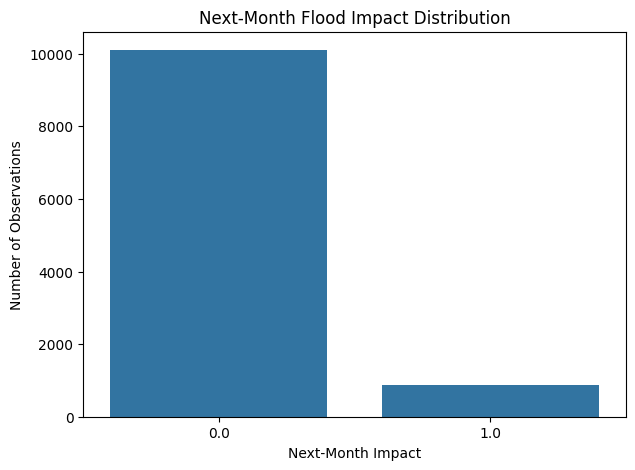

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(
    x=y
)

plt.title(
    "Next-Month Flood Impact Distribution"
)

plt.xlabel(
    "Next-Month Impact"
)

plt.ylabel(
    "Number of Observations"
)

plt.show()

#Feature statistics

In [61]:
print("Summary Statistics of the 20 Features:")

display(
    X.describe().T
)

Summary Statistics of the 20 Features:


,count,mean,std,min,25%,50%,75%,max
max_rain,10980.0,0.328544,0.364511,0.000000,0.033535,0.234592,0.497069,2.780199
mean_rain,10980.0,0.273258,0.310130,0.000000,0.023715,0.189438,0.409772,2.681264
sum_rain,10980.0,102.875236,160.479522,0.000000,4.243437,41.973334,134.167396,2113.367071
mean_ndvi,10980.0,0.472135,0.136757,-0.098735,0.391052,0.485502,0.561583,0.887988
mean_ndbi,10980.0,-0.122881,0.092064,-0.579713,-0.185600,-0.125146,-0.054974,0.128507
sum_population,10980.0,200339.092482,136607.397268,147.727197,106905.579687,174818.996875,270639.153125,771952.975000
sum_aged_population,10980.0,9458.244612,7572.323716,0.594000,3713.937000,7641.262000,13837.884000,49578.404000
sum_young_population,10980.0,16528.075393,13877.284290,1.076000,6344.075750,12336.377000,22907.721000,76635.776000
mean_sex_ratio,10980.0,0.936880,0.009516,0.903430,0.930781,0.938058,0.942053,0.955698
total_hhd,10980.0,43846.600000,34724.357659,0.000000,21471.000000,38531.000000,56887.500000,257725.000000


#Feature distributions

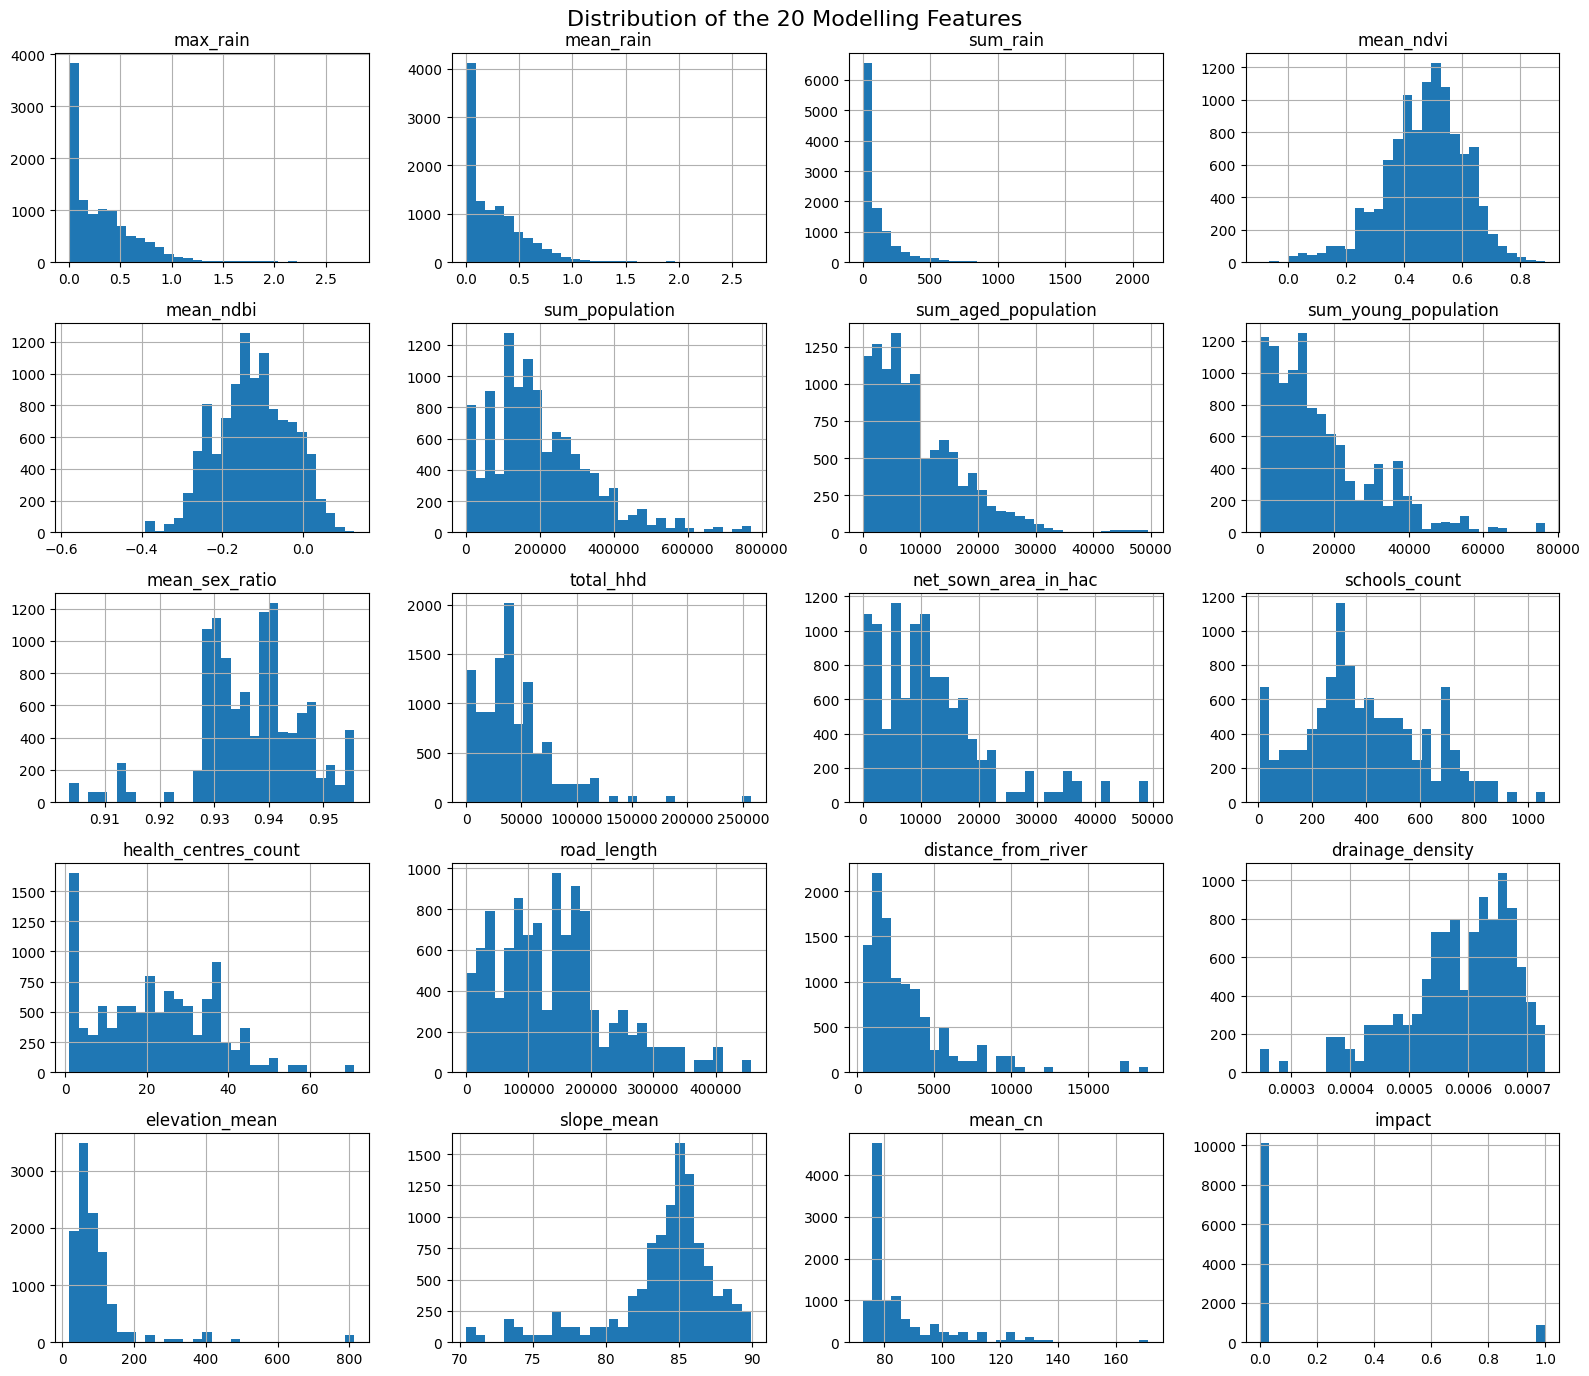

In [62]:
X.hist(
    figsize=(16, 14),
    bins=30
)

plt.suptitle(
    "Distribution of the 20 Modelling Features",
    fontsize=16
)

plt.tight_layout()

plt.show()

#Correlation with target

In [65]:
numeric_features = [col for col in features if col not in ['object_id', 'timeperiod']]

target_correlation = (
    model_df[numeric_features + [target]]
    .corr()[target]
    .drop(target)
    .sort_values()
)

print(
    "Correlation of Features with Next-Month Impact:"
)

display(
    target_correlation.to_frame(
        name="Correlation"
    )
)

Correlation of Features with Next-Month Impact:


,Correlation
slope_mean,-0.069392
mean_ndvi,-0.046478
elevation_mean,-0.023281
distance_from_river,0.001199
mean_sex_ratio,0.022822
drainage_density,0.026773
mean_cn,0.031802
mean_ndbi,0.038684
total_hhd,0.070280
sum_young_population,0.071590


#Correlation chart

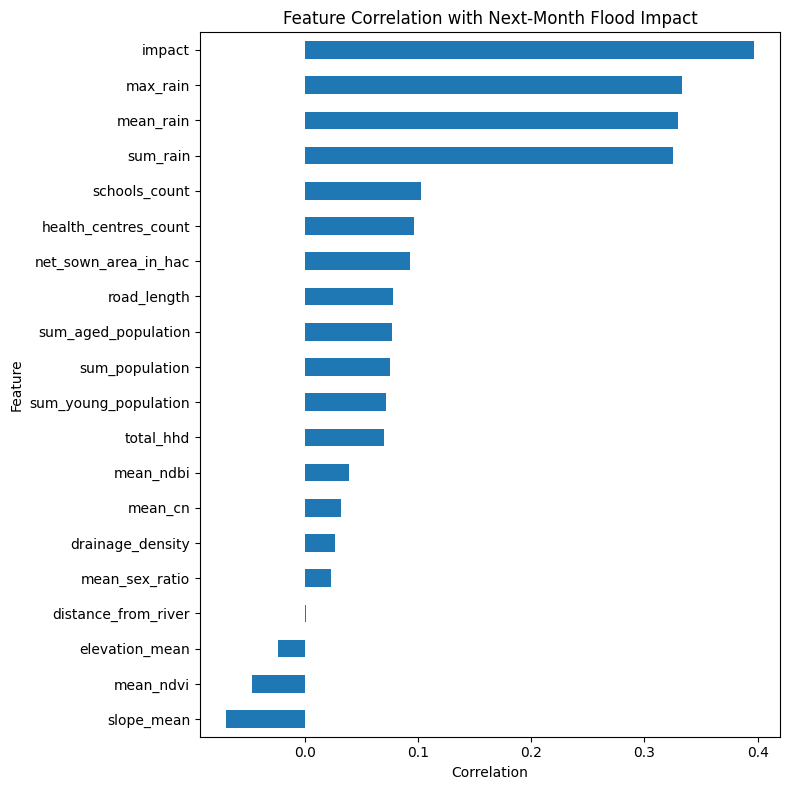

In [66]:
plt.figure(figsize=(8, 8))

target_correlation.plot(
    kind="barh"
)

plt.title(
    "Feature Correlation with Next-Month Flood Impact"
)

plt.xlabel(
    "Correlation"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()

In [67]:
print("Dataset columns:")

for i, column in enumerate(model_df.columns, start=1):
    print(i, column)

Dataset columns:
1 object_id
2 timeperiod
3 max_rain
4 mean_rain
5 sum_rain
6 mean_ndvi
7 mean_ndbi
8 sum_population
9 sum_aged_population
10 sum_young_population
11 mean_sex_ratio
12 total_hhd
13 net_sown_area_in_hac
14 schools_count
15 health_centres_count
16 road_length
17 distance_from_river
18 drainage_density
19 elevation_mean
20 slope_mean
21 mean_cn
22 impact
23 next_month_impact


In [69]:
target = "next_month_impact"

id_column = "object_id"

time_column = "timeperiod"

features = [
    "max_rain",
    "mean_rain",
    "sum_rain",
    "mean_ndvi",
    "mean_ndbi",
    "sum_population",
    "sum_aged_population",
    "sum_young_population",
    "mean_sex_ratio",
    "total_hhd",
    "net_sown_area_in_hac",
    "schools_count",
    "health_centres_count",
    "road_length",
    "distance_from_river",
    "drainage_density",
    "elevation_mean",
    "slope_mean",
    "mean_cn",
    "impact"
]

print("Number of modelling features:", len(features))

Number of modelling features: 20


In [70]:
required_columns = features + [
    id_column,
    time_column,
    target
]

missing_columns = [
    column
    for column in required_columns
    if column not in model_df.columns
]

if len(missing_columns) == 0:
    print("All required columns are present.")
else:
    print("Missing columns:")
    print(missing_columns)

All required columns are present.


In [73]:
model_df[time_column] = pd.to_datetime(
    model_df[time_column],
    format='%Y_%m'
)

print("Earliest date:")
print(model_df[time_column].min())

print("\nLatest date:")
print(model_df[time_column].max())

Earliest date:
2021-04-01 00:00:00

Latest date:
2026-04-01 00:00:00


In [74]:
model_df = model_df.sort_values(
    [time_column, id_column]
).reset_index(
    drop=True
)

print("Data sorted chronologically.")

Data sorted chronologically.


#Proper temporal train/test split

In [75]:
unique_months = sorted(
    model_df[time_column].dt.to_period("M").unique()
)

split_position = int(
    len(unique_months) * 0.80
)

train_months = unique_months[:split_position]

test_months = unique_months[split_position:]

print("Number of training months:", len(train_months))
print("Number of testing months:", len(test_months))

print("\nTraining period:")
print(train_months[0], "to", train_months[-1])

print("\nTesting period:")
print(test_months[0], "to", test_months[-1])

Number of training months: 48
Number of testing months: 13

Training period:
2021-04 to 2025-03

Testing period:
2025-04 to 2026-04


#Create train and test datasets

In [76]:
train_df = model_df[
    model_df[time_column].dt.to_period("M").isin(train_months)
].copy()

test_df = model_df[
    model_df[time_column].dt.to_period("M").isin(test_months)
].copy()

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

Training rows: 8640
Testing rows: 2340


#Create X and y

In [77]:
X_train = train_df[features].copy()

X_test = test_df[features].copy()

y_train = train_df[target].astype(int).copy()

y_test = test_df[target].astype(int).copy()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8640, 20)
X_test : (2340, 20)
y_train: (8640,)
y_test : (2340,)


#Check class imbalance

In [78]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training target distribution:
next_month_impact
0    7901
1     739
Name: count, dtype: int64

Testing target distribution:
next_month_impact
0    2202
1     138
Name: count, dtype: int64


In [79]:
print("Training target percentage:")
print(
    (y_train.value_counts(normalize=True) * 100).round(2)
)

print("\nTesting target percentage:")
print(
    (y_test.value_counts(normalize=True) * 100).round(2)
)

Training target percentage:
next_month_impact
0    91.45
1     8.55
Name: proportion, dtype: float64

Testing target percentage:
next_month_impact
0    94.1
1     5.9
Name: proportion, dtype: float64


#Install required packages

In [80]:
!pip install -q catboost xgboost

# Import models and metrics

In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

#Calculate class weight

In [82]:
negative_count = (y_train == 0).sum()

positive_count = (y_train == 1).sum()

scale_pos_weight = (
    negative_count / positive_count
)

print("Negative samples:", negative_count)
print("Positive samples:", positive_count)

print(
    "Scale positive weight:",
    round(scale_pos_weight, 2)
)

Negative samples: 7901
Positive samples: 739
Scale positive weight: 10.69


#Model 1 — Logistic Regression

In [83]:
logistic_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(
    X_train,
    y_train
)

logistic_pred = logistic_model.predict(
    X_test
)

logistic_prob = logistic_model.predict_proba(
    X_test
)[:, 1]

print("Logistic Regression training completed.")

Logistic Regression training completed.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Model 2 — Random Forest




In [85]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

rf_prob = rf_model.predict_proba(
    X_test
)[:, 1]

print("Random Forest training completed.")

Random Forest training completed.


#Model 3 — XGBoost

In [86]:
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(
    X_test
)

xgb_prob = xgb_model.predict_proba(
    X_test
)[:, 1]

print("XGBoost training completed.")

XGBoost training completed.


#Model 4 — CatBoost

In [87]:
cat_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=False
)

cat_model.fit(
    X_train,
    y_train
)

cat_pred = cat_model.predict(
    X_test
).astype(int).ravel()

cat_prob = cat_model.predict_proba(
    X_test
)[:, 1]

print("CatBoost training completed.")

CatBoost training completed.


#Compare all models

In [88]:
results = []

models = {
    "Logistic Regression": (logistic_pred, logistic_prob),
    "Random Forest": (rf_pred, rf_prob),
    "XGBoost": (xgb_pred, xgb_prob),
    "CatBoost": (cat_pred, cat_prob)
}

for model_name, (predictions, probabilities) in models.items():

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            probabilities
        )
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "F1 Score",
    ascending=False
)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,XGBoost,0.888034,0.272059,0.536232,0.360976,0.848191
3,CatBoost,0.852991,0.224599,0.608696,0.328125,0.856129
1,Random Forest,0.913248,0.300613,0.355072,0.325581,0.855795
0,Logistic Regression,0.783761,0.170251,0.688406,0.272989,0.805375


#Visual comparison

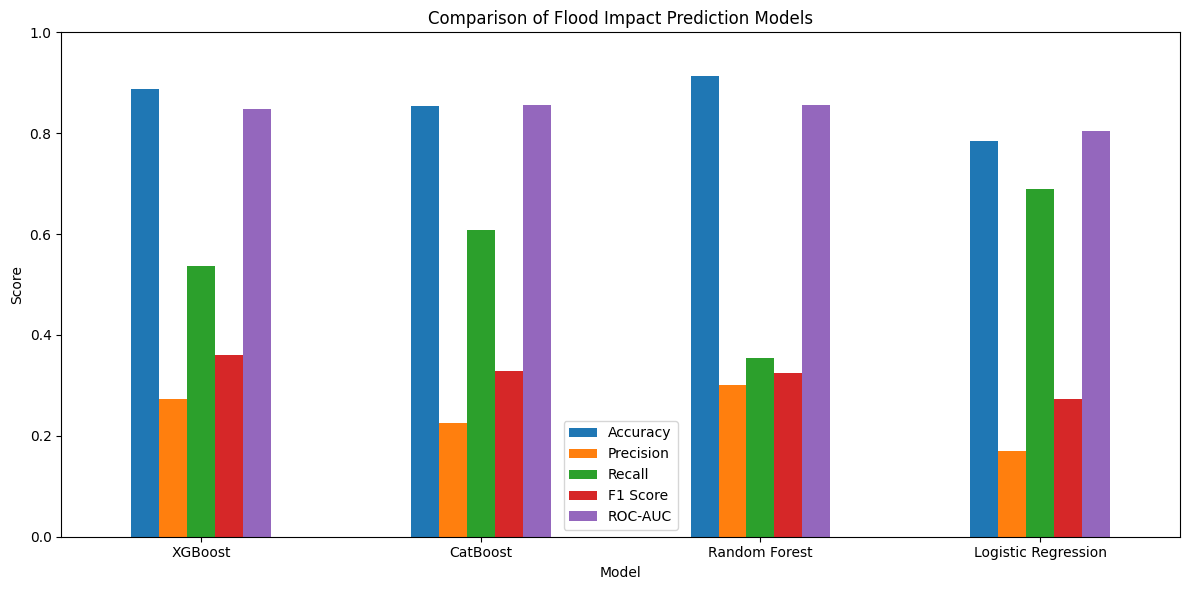

In [89]:
results_plot = results_df.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
]

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Comparison of Flood Impact Prediction Models"
)

plt.ylabel(
    "Score"
)

plt.xlabel(
    "Model"
)

plt.xticks(
    rotation=0
)

plt.ylim(
    0,
    1
)

plt.tight_layout()

plt.show()

#Find the best model

In [90]:
best_model_name = results_df.iloc[0]["Model"]

print(
    "Best model based on F1 Score:",
    best_model_name
)

Best model based on F1 Score: XGBoost


#Detailed evaluation of CatBoost

In [91]:
print("CatBoost Classification Report")
print("--------------------------------")

print(
    classification_report(
        y_test,
        cat_pred,
        zero_division=0
    )
)

CatBoost Classification Report
--------------------------------
              precision    recall  f1-score   support

           0       0.97      0.87      0.92      2202
           1       0.22      0.61      0.33       138

    accuracy                           0.85      2340
   macro avg       0.60      0.74      0.62      2340
weighted avg       0.93      0.85      0.88      2340



#Confusion Matrix

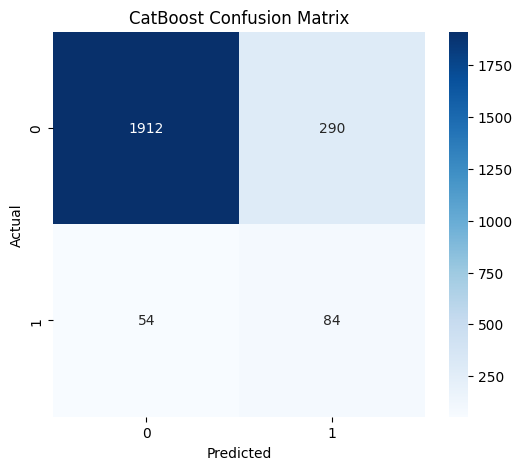

In [92]:
cm = confusion_matrix(
    y_test,
    cat_pred
)

plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "CatBoost Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

In [93]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": cat_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(
    feature_importance
)

,Feature,Importance
0,max_rain,16.025248
1,mean_rain,12.332859
2,sum_rain,10.286147
4,mean_ndbi,8.554077
3,mean_ndvi,5.799959
16,elevation_mean,4.629164
8,mean_sex_ratio,4.556914
18,mean_cn,3.808341
10,net_sown_area_in_hac,3.612214
15,drainage_density,3.578748


#Feature importance chart

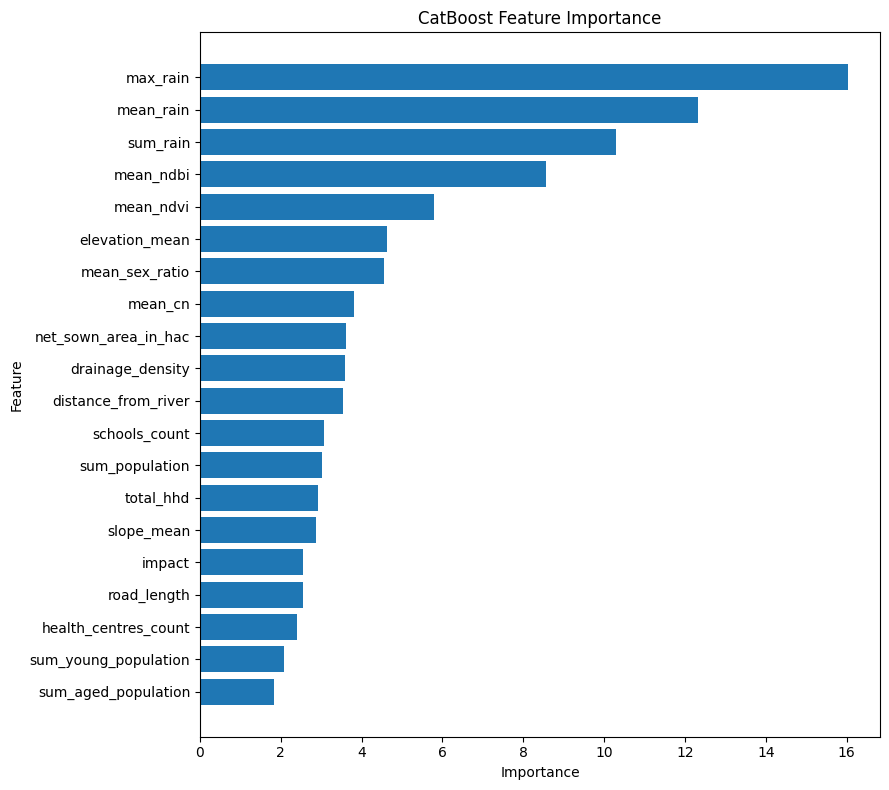

In [94]:
plt.figure(
    figsize=(9, 8)
)

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "CatBoost Feature Importance"
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()